# US Sheep & Goat Price Index — Closing the Price-Discovery Gap

**Problem.** Beef, pork, and chicken have deep futures markets and mandatory price
reporting. Sheep and goat do not: prices live in fragmented weekly auction reports
that producers cannot easily compare across time or region. That opacity is the
market inefficiency this notebook starts to fix.

**What we build.**
1. A **national slaughter-lamb price index** from USDA AMS Weekly National Sheep
   Summaries (SA_LS855), reconstructed from the live report + Wayback Machine
   snapshots (~2000–present) — no API key required.
2. **Regional basis** — how San Angelo, New Holland, Billings, etc. trade relative
   to the national average (the classic signal of local over/under-pricing).
3. A **goat vs lamb snapshot** from the two largest auctions (San Angelo TX,
   New Holland PA) using current AMS graded PDF reports — goats are missing from
   the national sheep summary entirely.

**Data note.** Historical coverage is denser for sheep/lamb than goat because AMS
publishes a national sheep text summary but not an equivalent national goat summary.
Goat price discovery is the thinner market — and therefore the larger opportunity.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from ams_reports import (
    build_lamb_index,
    fetch_major_auction_lots,
    fetch_sheep_quotes,
)

sns.set_theme(style="whitegrid", context="notebook")
FIG_DIR = PROJECT_ROOT / "outputs" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR = PROJECT_ROOT / "outputs"
OUT_DIR.mkdir(exist_ok=True)

# First run downloads Wayback snapshots (a few minutes). Later runs use cache.
quotes = fetch_sheep_quotes(max_snapshots=100, refresh=False)
lots = fetch_major_auction_lots(refresh=False)

print(f"Parsed quotes: {len(quotes):,} rows | "
      f"{quotes['report_date'].min():%Y-%m-%d} → {quotes['report_date'].max():%Y-%m-%d}")
print(f"Markets: {sorted(quotes['market'].dropna().unique())}")
print(f"Auction lots (latest PDFs): {len(lots)} rows")
quotes.head()

Parsed quotes: 3,449 rows | 2000-01-07 → 2026-08-07
Markets: ['Arkansas', 'Billings', 'Eastern Area', 'Equity Coop', 'Ft. Collins', 'Kalona', 'Midwest', 'Missouri', 'Mount Hope', 'New Holland', 'San Angelo', 'Sioux Falls', 'South Dakota']
Auction lots (latest PDFs): 122 rows


,report_date,section,market,wt_lo,wt_hi,price_lo,price_hi,price_mid,source
0,2000-01-07,slaughter_lambs,San Angelo,NaN,NaN,75.0,81.50,78.250,wayback:20000111094139
1,2000-01-07,slaughter_lambs,Midwest,NaN,NaN,64.0,73.00,68.500,wayback:20000111094139
2,2000-01-07,slaughter_lambs,Midwest,NaN,NaN,62.0,70.75,66.375,wayback:20000111094139
3,2000-01-07,slaughter_lambs,Kalona,NaN,NaN,64.5,73.00,68.750,wayback:20000111094139
4,2000-01-07,slaughter_lambs,Kalona,NaN,NaN,62.0,71.25,66.625,wayback:20000111094139


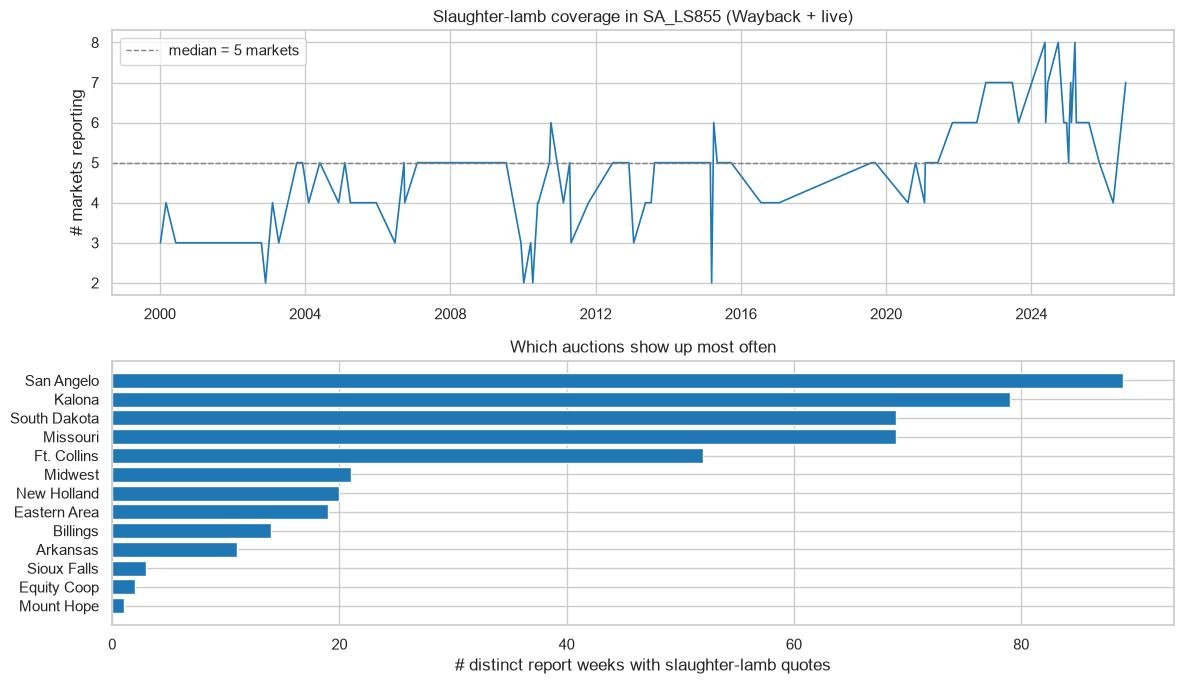

Distinct weeks with any slaughter-lamb quotes: 93
Median markets/week: 5.0


In [2]:
# --- Coverage: how thin is the historical record? ---------------------------
coverage = (
    quotes[quotes["section"] == "slaughter_lambs"]
    .groupby(["report_date", "market"])
    .size()
    .reset_index(name="n_quotes")
)
weeks = coverage.groupby("report_date")["market"].nunique()

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=False)
axes[0].plot(weeks.index, weeks.values, lw=1.2, color="tab:blue")
axes[0].set_ylabel("# markets reporting")
axes[0].set_title("Slaughter-lamb coverage in SA_LS855 (Wayback + live)")
axes[0].axhline(weeks.median(), color="grey", ls="--", lw=1,
                label=f"median = {weeks.median():.0f} markets")
axes[0].legend()

counts = coverage.groupby("market")["report_date"].nunique().sort_values(ascending=True)
axes[1].barh(counts.index, counts.values, color="tab:blue")
axes[1].set_xlabel("# distinct report weeks with slaughter-lamb quotes")
axes[1].set_title("Which auctions show up most often")
plt.tight_layout()
plt.savefig(FIG_DIR / "10_sheep_coverage.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Distinct weeks with any slaughter-lamb quotes: {weeks.shape[0]}")
print(f"Median markets/week: {weeks.median():.1f}")

## National slaughter-lamb index

Equal-weight average of market-week midpoints for Choice/Prime slaughter lambs in
the ~80–130 lb band (the most consistently reported commercial class). Older
reports that only quote a 90–160 lb class without band detail are included too.

This is deliberately simple and transparent — a first public index, not a CME
settlement. The point is that **no continuous series like this currently exists
on a free public dashboard**.

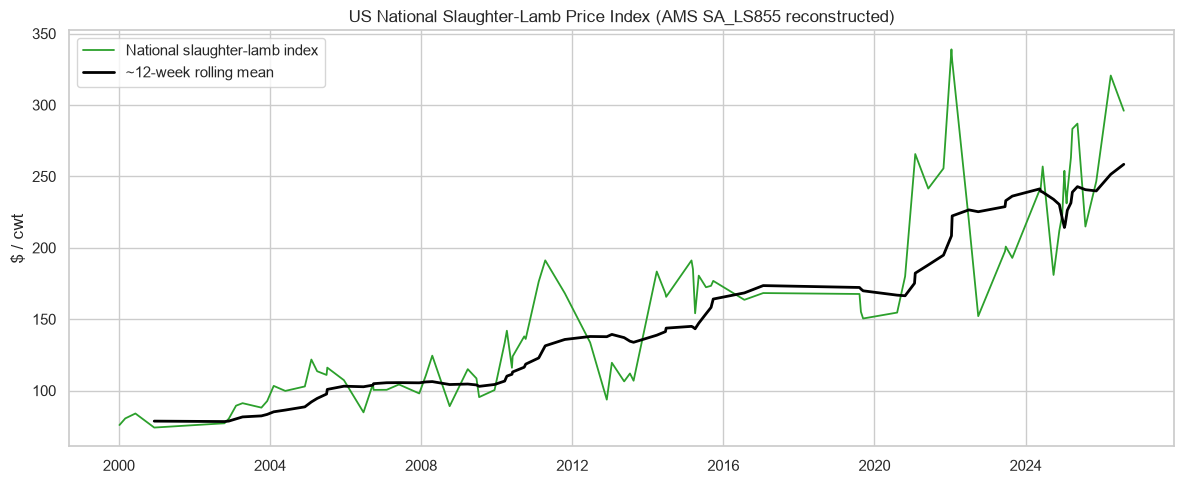

Index span: 2000-01-07 → 2026-08-07
Latest index: $295.98/cwt across 5 markets
Saved → outputs/lamb_national_index.csv


In [3]:
panel = build_lamb_index(quotes, section="slaughter_lambs", wt_lo=80, wt_hi=130)
national = (
    panel.drop_duplicates("report_date")
    .set_index("report_date")[["national_index", "n_markets"]]
    .sort_index()
)

# Require at least 2 markets so a single thin auction cannot set the index
national = national[national["n_markets"] >= 2]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(national.index, national["national_index"], lw=1.3, color="tab:green",
        label="National slaughter-lamb index")
ax.plot(national.index, national["national_index"].rolling(12, min_periods=4).mean(),
        lw=2, color="black", label="~12-week rolling mean")
ax.set_ylabel("$ / cwt")
ax.set_title("US National Slaughter-Lamb Price Index (AMS SA_LS855 reconstructed)")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "11_lamb_national_index.png", dpi=150, bbox_inches="tight")
plt.show()

# Persist for GitHub / outreach
national.to_csv(OUT_DIR / "lamb_national_index.csv")
panel.to_csv(OUT_DIR / "lamb_market_basis.csv", index=False)
print(f"Index span: {national.index.min():%Y-%m-%d} → {national.index.max():%Y-%m-%d}")
print(f"Latest index: ${national['national_index'].iloc[-1]:.2f}/cwt "
      f"across {int(national['n_markets'].iloc[-1])} markets")
print(f"Saved → outputs/lamb_national_index.csv")

## Regional basis — where are animals under/over-priced?

Basis = market price − national index that week. Persistent positive basis means
a market usually pays a premium (often proximity to ethnic/halal demand or packing);
persistent negative basis means producers there leave money on the table relative
to the national average — exactly the inefficiency a transparent index helps close.

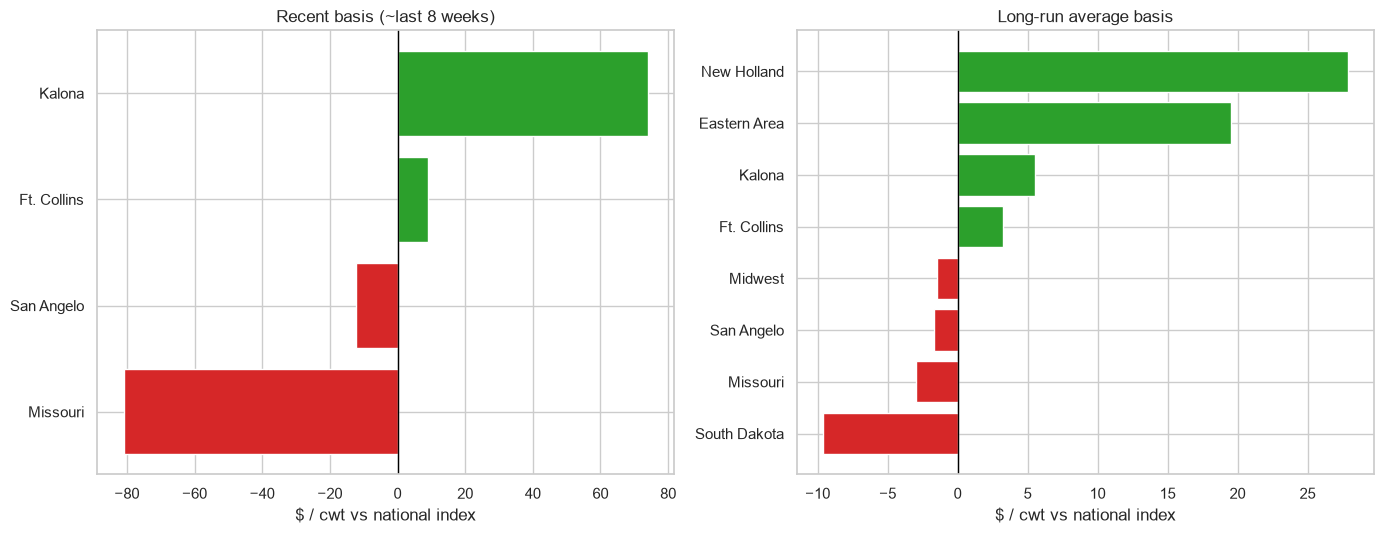

Recent basis ($/cwt):
market
Missouri      -80.98
San Angelo    -12.23
Ft. Collins     9.02
Kalona         74.02


In [4]:
# Focus on markets with enough history to be meaningful
min_weeks = 15
counts = panel.groupby("market")["report_date"].nunique()
keep_markets = counts[counts >= min_weeks].index
basis = panel[panel["market"].isin(keep_markets)].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Latest 8 weeks average basis by market
cutoff = basis["report_date"].max() - pd.Timedelta(days=60)
recent = basis[basis["report_date"] >= cutoff]
recent_avg = recent.groupby("market")["basis"].mean().sort_values()
colors = ["tab:red" if v < 0 else "tab:green" for v in recent_avg.values]
axes[0].barh(recent_avg.index, recent_avg.values, color=colors)
axes[0].axvline(0, color="black", lw=1)
axes[0].set_xlabel("$ / cwt vs national index")
axes[0].set_title("Recent basis (~last 8 weeks)")

# Long-run average basis
long_avg = basis.groupby("market")["basis"].mean().sort_values()
colors = ["tab:red" if v < 0 else "tab:green" for v in long_avg.values]
axes[1].barh(long_avg.index, long_avg.values, color=colors)
axes[1].axvline(0, color="black", lw=1)
axes[1].set_xlabel("$ / cwt vs national index")
axes[1].set_title("Long-run average basis")
plt.tight_layout()
plt.savefig(FIG_DIR / "12_lamb_regional_basis.png", dpi=150, bbox_inches="tight")
plt.show()

print("Recent basis ($/cwt):")
print(recent_avg.round(2).to_string())

## Goat vs lamb at the two largest auctions

San Angelo (TX) and New Holland (PA) publish graded sheep **and** goat lots in
their weekly AMS PDFs. The national sheep summary does not include goats — so
these two auctions are currently the best public window into US goat pricing.

We compare head-weighted average prices for slaughter-class kids/lambs to show
how the two proteins are priced *relative to each other* in the same ring on the
same day.

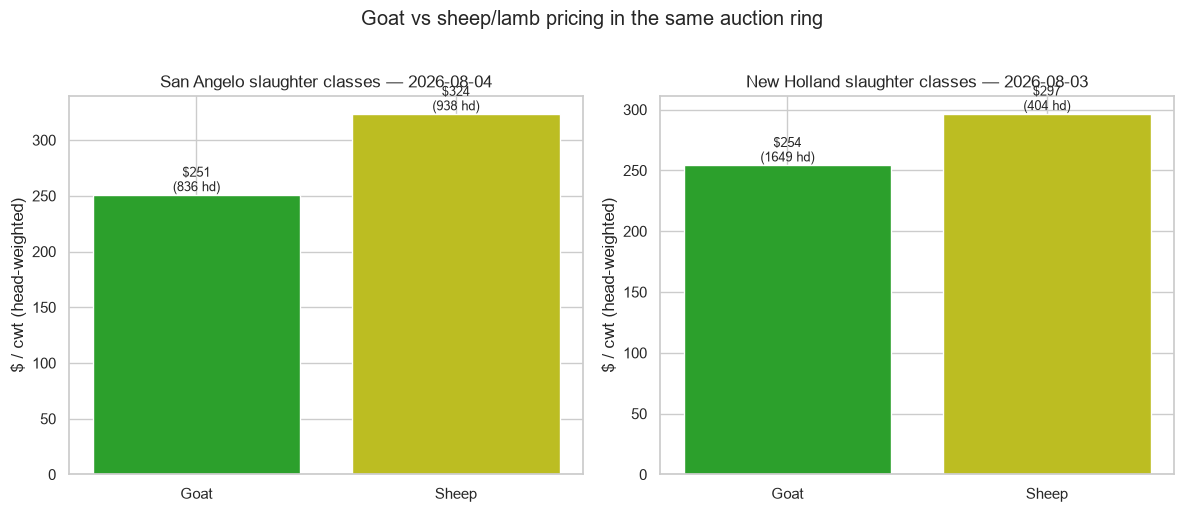

     market species report_date   head  wavg_price  n_lots
New Holland    goat  2026-08-03 1649.0      254.34    69.0
New Holland   sheep  2026-08-03  404.0      296.62    15.0
 San Angelo    goat  2026-08-04  836.0      251.13    22.0
 San Angelo   sheep  2026-08-04  938.0      323.67    16.0

Goat / lamb price ratio:
     market report_date  goat_lamb_ratio
New Holland  2026-08-03            0.857
 San Angelo  2026-08-04            0.776


C:\Users\alber\AppData\Local\Temp\ipykernel_6584\2030829427.py:51: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  print(summary.round(2).to_string(index=False))
C:\Users\alber\AppData\Local\Temp\ipykernel_6584\2030829427.py:54: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  print(pivot[["market", "report_date", "goat_lamb_ratio"]].round(3).to_string(index=False))


In [5]:
# Head-weighted average price by market × species for slaughter-ish sections
slaughterish = lots[
    lots["section"].str.contains("slaughter", case=False, na=False)
    & lots["species"].isin(["goat", "sheep"])
].copy()

def wavg(g):
    return np.average(g["avg_price"], weights=g["head"])

summary = (
    slaughterish.groupby(["market", "species", "report_date"])
    .apply(lambda g: pd.Series({
        "head": g["head"].sum(),
        "wavg_price": wavg(g),
        "n_lots": len(g),
    }), include_groups=False)
    .reset_index()
)

pivot = summary.pivot_table(
    index=["market", "report_date"], columns="species",
    values=["wavg_price", "head"], aggfunc="first"
)
# flatten columns
pivot.columns = [f"{a}_{b}" for a, b in pivot.columns]
pivot = pivot.reset_index()
if {"wavg_price_goat", "wavg_price_sheep"}.issubset(pivot.columns):
    pivot["goat_lamb_ratio"] = pivot["wavg_price_goat"] / pivot["wavg_price_sheep"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, market in zip(axes, ["San Angelo", "New Holland"]):
    sub = slaughterish[slaughterish["market"] == market]
    if sub.empty:
        ax.set_title(f"{market}: no lots parsed")
        continue
    by_sp = sub.groupby("species").apply(wavg, include_groups=False)
    heads = sub.groupby("species")["head"].sum()
    ax.bar(by_sp.index.str.title(), by_sp.values,
           color=["tab:green" if i == "goat" else "tab:olive" for i in by_sp.index])
    for i, (sp, px) in enumerate(by_sp.items()):
        ax.text(i, px + 3, f"${px:.0f}\n({int(heads[sp])} hd)", ha="center", fontsize=9)
    dt = sub["report_date"].dropna().iloc[0] if sub["report_date"].notna().any() else "?"
    ax.set_ylabel("$ / cwt (head-weighted)")
    ax.set_title(f"{market} slaughter classes — {dt:%Y-%m-%d}" if dt != "?" else market)

plt.suptitle("Goat vs sheep/lamb pricing in the same auction ring", y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "13_goat_vs_lamb_auctions.png", dpi=150, bbox_inches="tight")
plt.show()

print(summary.round(2).to_string(index=False))
if "goat_lamb_ratio" in pivot.columns:
    print("\nGoat / lamb price ratio:")
    print(pivot[["market", "report_date", "goat_lamb_ratio"]].round(3).to_string(index=False))
lots.to_csv(OUT_DIR / "major_auction_lots_latest.csv", index=False)

## Takeaways & how to use this as a door-opener

1. **A continuous national lamb index can be built from public scraps.** AMS already
   collects the data; it just isn't packaged as a usable time series. This notebook
   is that packaging.
2. **Regional basis is the actionable layer for producers.** A rancher near a
   persistently negative-basis market can quantify the cost of selling locally vs
   trucking to a premium ring — the classic job of price discovery.
3. **Goat is the thinner market.** No national text summary exists; discovery still
   depends on individual auction PDFs. Extending this pipeline to archive goat lots
   weekly (San Angelo + New Holland + Columbia TN + others) is the highest-leverage
   next product feature.
4. **Optional upgrade path:** register for a free MARS API key
   (`MARS_API_KEY` in `.env`) to pull structured history instead of Wayback/PDF
   parsing — same index, cleaner plumbing.

**Outreach draft (send with the CSV + one chart):**
> I reconstructed a weekly US slaughter-lamb price index and regional basis series
> from AMS SA_LS855 reports (2000–present) and compared goat vs lamb pricing at
> San Angelo and New Holland. Happy to share the data / methodology if useful to
> your market-news or producer outreach work.